In [2]:
# Install necessary libraries
# !pip install gymnasium[box2d] stable-baselines3 shimmy imageio numpy matplotlib pandas

import os
import imageio
import numpy as np
import torch as nn
import pandas as pd
import gymnasium as gym
from typing import Callable
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv, VecMonitor

# Create directories for logging and models
LOG_DIR = "./logs/"
os.makedirs(LOG_DIR, exist_ok=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Eval num_timesteps=20000, episode_reward=-45.54 +/- 40.27
Episode length: 1006.40 +/- 727.02
New best mean reward!
Eval num_timesteps=40000, episode_reward=-119.06 +/- 0.15
Episode length: 115.40 +/- 2.80
Eval num_timesteps=60000, episode_reward=-30.30 +/- 13.10
Episode length: 1600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=80000, episode_reward=-55.16 +/- 34.13
Episode length: 997.00 +/- 738.53
Eval num_timesteps=100000, episode_reward=-39.50 +/- 3.33
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=120000, episode_reward=-56.23 +/- 5.66
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=140000, episode_reward=-39.99 +/- 3.87
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=160000, episode_reward=-43.38 +/- 10.05
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=180000, episode_reward=-43.34 +/- 4.84
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=200000, episode_reward=-38.45 +/- 0.10
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=220000, episode_reward=-

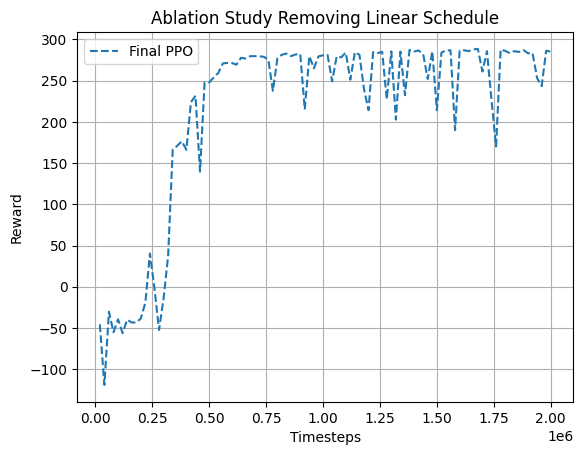

In [2]:
import gymnasium as gym
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# 1. CONSTANTS
LOG_DIR = "./logs_ablation/"
DYNAMIC_STEPS = 2_000_000  # BipedalWalker often needs >1M to perfect gait
N_ENVS = 8                # Number of parallel environments

# 2. LEARNING RATE SCHEDULE
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# 3. ENVIRONMENT SETUP (Vectorized)
# make_vec_env handles the creation of multiple processes automatically
env_dynamic = make_vec_env("BipedalWalker-v3", n_envs=N_ENVS)

# Normalize observations and rewards (Crucial for PPO/BipedalWalker)
env_dynamic = VecNormalize(
    env_dynamic, 
    norm_obs=True, 
    norm_reward=True, 
    clip_obs=10.,
    gamma=0.99
)

# 4. CALLBACKS
# Separate evaluation env to test true performance without exploration noise/normalization updates
eval_env = make_vec_env("BipedalWalker-v3", n_envs=1)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=LOG_DIR + "No_linear_schedule",
    log_path=LOG_DIR + "No_linear_schedule",
    eval_freq=max(20000 // N_ENVS, 1), # Adjust frequency for parallel envs
    deterministic=True,
    render=False
)

# 5. MODEL CONFIGURATION
dynamic_model = PPO(
    "MlpPolicy",
    env_dynamic,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    use_sde=True,
    sde_sample_freq=4,
    verbose=0,
    seed=42,
    policy_kwargs=dict(
        log_std_init=-2,
        ortho_init=True,
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[256, 256], vf=[256, 256])
    )
)

# print("Training Dynamic Model with gSDE and Parallel Envs...")
# Note: total_timesteps is distributed across all envs
dynamic_model.learn(total_timesteps=DYNAMIC_STEPS, callback=eval_callback)

# Save final model and the normalization stats
# dynamic_model.save(LOG_DIR + "No_linear_schedule")
env_dynamic.save(LOG_DIR + "No_linear_schedule.pkl")
print("Training Complete.")

eval_data = np.load(LOG_DIR + "No_linear_schedule/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study Removing Linear Schedule")
plt.legend()
plt.grid(True)

plt.savefig("ablation_linear_schedule.png")
plt.show()

In [8]:
import gymnasium as gym
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# 1. CONSTANTS
LOG_DIR = "./logs_ablation/"
DYNAMIC_STEPS = 2_000_000  # BipedalWalker often needs >1M to perfect gait
N_ENVS = 8                # Number of parallel environments

# 2. LEARNING RATE SCHEDULE
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# 3. ENVIRONMENT SETUP (Vectorized)
env_dynamic = make_vec_env("BipedalWalker-v3", n_envs=N_ENVS)

env_dynamic = VecNormalize(
    env_dynamic, 
    norm_obs=True, 
    norm_reward=True, 
    clip_obs=10.,
    gamma=0.99
)

# 4. CALLBACKS
eval_env = make_vec_env("BipedalWalker-v3", n_envs=1)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=LOG_DIR + "Small_network",
    log_path=LOG_DIR + "Small_network",
    eval_freq=max(20000 // N_ENVS, 1), # Adjust frequency for parallel envs
    deterministic=True,
    render=False
)

# 5. MODEL CONFIGURATION
dynamic_model = PPO(
    "MlpPolicy",
    env_dynamic,
    learning_rate=linear_schedule(3e-4),
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    use_sde=True,
    sde_sample_freq=4,
    verbose=0,
    seed=42,
    policy_kwargs=dict(
        activation_fn=nn.Tanh,
        ortho_init=True,
        net_arch=dict(pi=[64, 64], vf=[64, 64])
    )
)

# print("Training Dynamic Model with gSDE and Parallel Envs...")
# Note: total_timesteps is distributed across all envs
dynamic_model.learn(total_timesteps=DYNAMIC_STEPS, callback=eval_callback)

# Save final model and the normalization stats
# dynamic_model.save(LOG_DIR + "No_linear_schedule")
env_dynamic.save(LOG_DIR + "Small_network.pkl")
print("Training Complete.")

eval_data = np.load(LOG_DIR + "Small_network/Small_network.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study with Small network")
plt.legend()
plt.grid(True)

plt.savefig("ablation_small_network.png")
plt.show()

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Eval num_timesteps=20000, episode_reward=-82.40 +/- 21.98
Episode length: 1014.60 +/- 716.97
New best mean reward!
Eval num_timesteps=40000, episode_reward=-116.74 +/- 10.84
Episode length: 105.60 +/- 17.45
Eval num_timesteps=60000, episode_reward=-102.62 +/- 17.22
Episode length: 1038.80 +/- 687.42
Eval num_timesteps=80000, episode_reward=-130.18 +/- 0.15
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=100000, episode_reward=-139.90 +/- 0.94
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=120000, episode_reward=-135.22 +/- 3.83
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=140000, episode_reward=-134.74 +/- 8.40
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=160000, episode_reward=-138.14 +/- 0.37
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=180000, episode_reward=-121.85 +/- 11.12
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=200000, episode_reward=-117.81 +/- 3.71
Episode length: 1600.00 +/- 0.00
Eval num_timesteps=220000, episode_reward=-104.07 +/- 3

FileNotFoundError: [Errno 2] No such file or directory: './logs_ablation/Small_network/Small_network.npz'

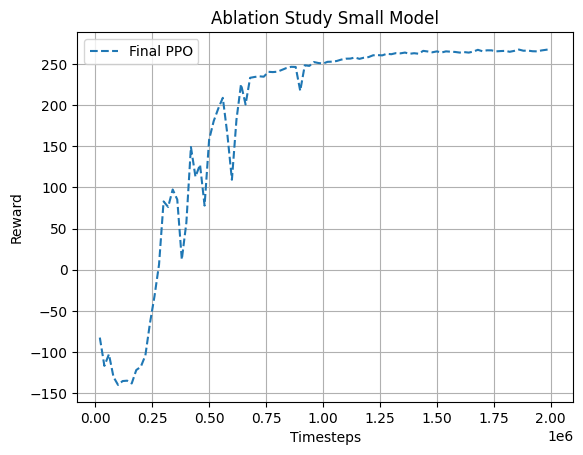

In [10]:
eval_data = np.load("logs_ablation/Small_network/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study Small Model")
plt.legend()
plt.grid(True)

plt.savefig("ablation_linear_schedule.png")
plt.show()

Eval num_timesteps=20000, episode_reward=-92.26 +/- 0.26
Episode length: 117.60 +/- 1.96
New best mean reward!
Eval num_timesteps=40000, episode_reward=-92.53 +/- 0.39
Episode length: 130.80 +/- 2.99
Eval num_timesteps=60000, episode_reward=-92.72 +/- 0.50
Episode length: 113.80 +/- 1.94
Eval num_timesteps=80000, episode_reward=-93.69 +/- 2.14
Episode length: 152.20 +/- 2.71
Eval num_timesteps=100000, episode_reward=-10.54 +/- 0.25
Episode length: 1600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=120000, episode_reward=-90.28 +/- 43.33
Episode length: 408.60 +/- 595.70
Eval num_timesteps=140000, episode_reward=-92.48 +/- 0.24
Episode length: 133.80 +/- 1.33
Eval num_timesteps=160000, episode_reward=-93.64 +/- 2.71
Episode length: 163.80 +/- 4.53
Eval num_timesteps=180000, episode_reward=-112.13 +/- 0.16
Episode length: 104.20 +/- 0.75
Eval num_timesteps=200000, episode_reward=-1.64 +/- 0.73
Episode length: 1600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=220000, episod

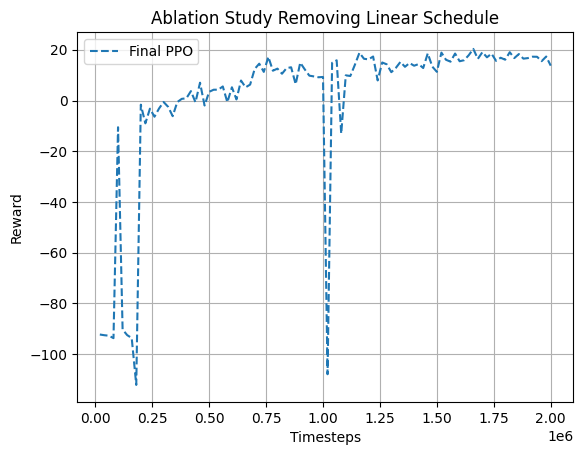

In [13]:
import gymnasium as gym
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# 1. CONSTANTS
LOG_DIR = "./logs_ablation/"
DYNAMIC_STEPS = 2_000_000  # BipedalWalker often needs >1M to perfect gait
N_ENVS = 8                # Number of parallel environments

# 2. LEARNING RATE SCHEDULE
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# 3. ENVIRONMENT SETUP (Vectorized)
# make_vec_env handles the creation of multiple processes automatically
env_dynamic = make_vec_env("BipedalWalker-v3", n_envs=N_ENVS)

# Normalize observations and rewards (Crucial for PPO/BipedalWalker)
env_dynamic = VecNormalize(
    env_dynamic, 
    norm_obs=True, 
    norm_reward=True, 
    clip_obs=10.,
    gamma=0.99
)

# 4. CALLBACKS
# Separate evaluation env to test true performance without exploration noise/normalization updates
eval_env = make_vec_env("BipedalWalker-v3", n_envs=1)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=LOG_DIR + "No_gsde",
    log_path=LOG_DIR + "No_gsde",
    eval_freq=max(20000 // N_ENVS, 1), # Adjust frequency for parallel envs
    deterministic=True,
    render=False
)

# 5. MODEL CONFIGURATION
dynamic_model = PPO(
    "MlpPolicy",
    env_dynamic,
    learning_rate=linear_schedule(3e-4),
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    use_sde=False,
    sde_sample_freq=4,
    verbose=0,
    seed=42,
    policy_kwargs=dict(
        log_std_init=-2,
        ortho_init=True,
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[256, 256], vf=[256, 256])
    )
)

# print("Training Dynamic Model with gSDE and Parallel Envs...")
# Note: total_timesteps is distributed across all envs
dynamic_model.learn(total_timesteps=DYNAMIC_STEPS, callback=eval_callback)

# Save final model and the normalization stats
# dynamic_model.save(LOG_DIR + "No_linear_schedule")
env_dynamic.save(LOG_DIR + "No_gsde.pkl")
print("Training Complete.")

eval_data = np.load(LOG_DIR + "No_gsde/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study Removing Linear Schedule")
plt.legend()
plt.grid(True)

plt.savefig("ablation_linear_schedule.png")
plt.show()

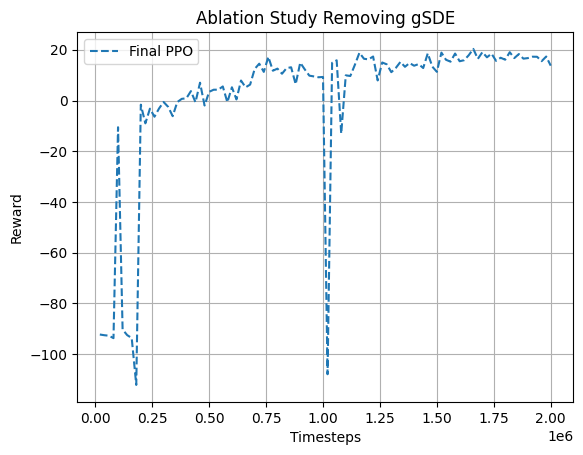

In [14]:
eval_data = np.load("logs_ablation/No_gsde/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study Removing gSDE")
plt.legend()
plt.grid(True)

plt.savefig("ablation_linear_schedule.png")
plt.show()

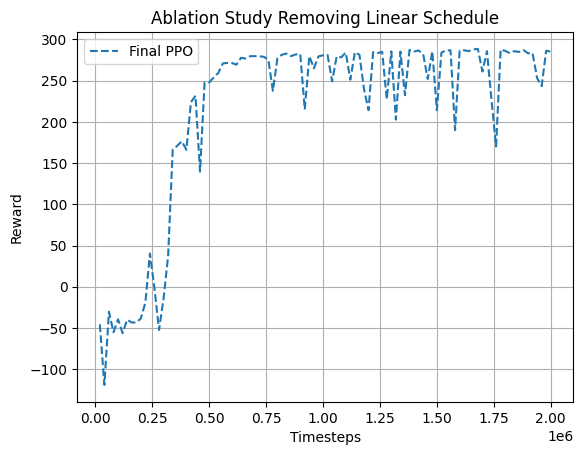

In [6]:
eval_data = np.load("logs_ablation/No_linear_schedule/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study Removing Linear Schedule")
plt.legend()
plt.grid(True)

plt.savefig("ablation_linear_schedule.png")
plt.show()

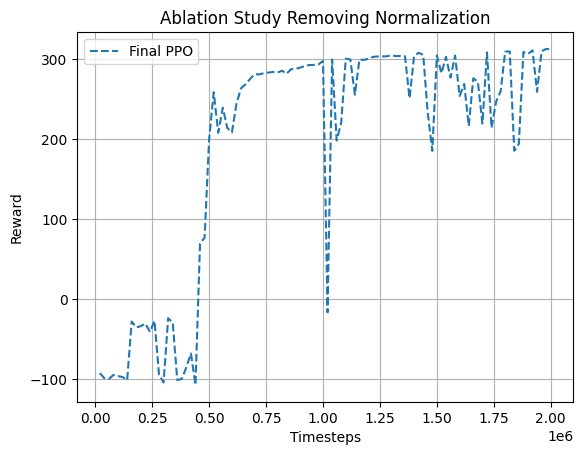

In [7]:
eval_data = np.load("logs_ablation/No_Normalization/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Ablation Study Removing Normalization")
plt.legend()
plt.grid(True)

plt.savefig("ablation_linear_schedule.png")
plt.show()

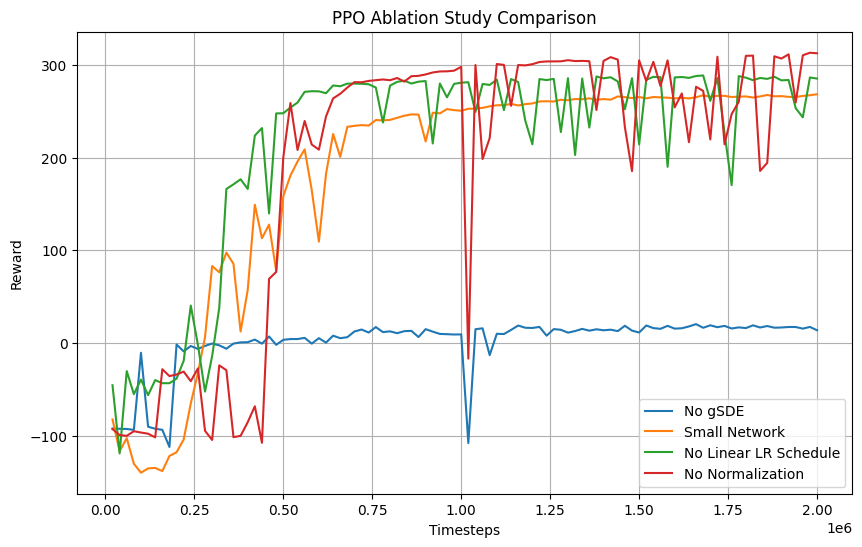

In [16]:
import numpy as np
import matplotlib.pyplot as plt

ablations = {
    "No gSDE": "logs_ablation/No_gsde/evaluations.npz",
    "Small Network": "logs_ablation/Small_network/evaluations.npz",
    "No Linear LR Schedule": "logs_ablation/No_linear_schedule/evaluations.npz",
    "No Normalization": "logs_ablation/No_Normalization/evaluations.npz",
}

plt.figure(figsize=(10, 6))

for label, path in ablations.items():
    eval_data = np.load(path)
    timesteps = eval_data["timesteps"]
    results = eval_data["results"]

    mean = np.mean(results, axis=1)

    plt.plot(timesteps, mean, label=label)

plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("PPO Ablation Study Comparison")
plt.legend()
plt.grid(True)

plt.savefig("ablation_comparison.png")
plt.show()
